Original Image


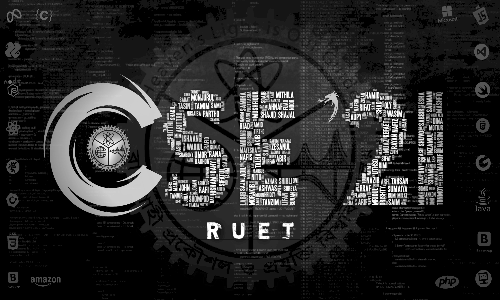

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import cv2

img=cv2.imread("/content/CSE-RUET Logo.png",cv2.IMREAD_GRAYSCALE)
H=500
W=300
img=cv2.resize(img,(H,W))
print("Original Image")
cv2_imshow(img)

# Image Negative:
def Negative(img):
  # neg_image=255-img # single statement.
  neg_img=np.zeros(img.shape)
  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      neg_img[i][j]=255-img[i][j]
  return neg_img

# Image Padding:
def Padding(img,pad,neigbor_pad):
  # padded=cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REPLICATE)

  w,h=img.shape[0]+pad*2,img.shape[1]+pad*2
  padded=np.zeros((w,h))
  # for original image
  padded[pad:pad+W , pad:pad+H]=img

  if neigbor_pad:
    padded[0:pad , pad:pad+H]=img[0] # top part
    padded[pad+W:pad+W+pad, pad:pad+H]=img[-1] # bottom part

    padded[:, 0:pad]=padded[:, pad:pad+1] # left part
    padded[:, pad+H:pad+H+pad] = padded[:, pad+H-1:pad+H] # right part

  return padded

Negative Image


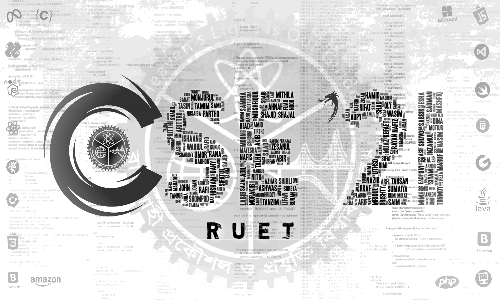

Padded Image


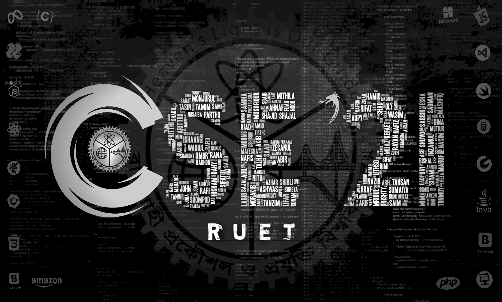

In [ ]:
print("Negative Image")
cv2_imshow(Negative(img))

print("Padded Image")
cv2_imshow(Padding(img,1,True))

In [ ]:
class SpatialFilters:

    def __init__(self, image_path,W,H):
        self.image=cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
        self.image=cv2.resize(self.image,(H,W))
        self.w=self.image.shape[0]
        self.h=self.image.shape[1]

    def _clip_and_convert(self, img):
        """Helper method to clip values to 0-255 and convert to uint8."""
        return np.clip(img, 0, 255).astype(np.uint8)

    # ==========================================
    # Linear Spatial Filtering
    # ==========================================

    def spatial_correlation(self, kernel):
        """Applies spatial correlation using a given kernel."""
        # cv2.filter2D computes correlation by default
        result = cv2.filter2D(self.image, -1, kernel)
        return self._clip_and_convert(result)

    def spatial_convolution(self, kernel):
        """Applies spatial convolution (rotates kernel by 180 degrees first)."""
        flipped_kernel = cv2.flip(kernel, -1)
        result = cv2.filter2D(self.image, -1, flipped_kernel)
        return self._clip_and_convert(result)

    # ==========================================
    # Linear Smoothing Spatial Filters
    # ==========================================

    def box_filter(self, kernel_size: int = 3):
        """Applies a Box Filter (average filter) for smoothing."""
        kernel = np.ones((kernel_size, kernel_size), np.float64) / (kernel_size ** 2)
        return self.spatial_correlation(kernel)

    def weighted_average_filter(self):
        """Applies a standard 3x3 Weighted Average Filter."""
        kernel = np.array([[1, 2, 1],
                           [2, 4, 2],
                           [1, 2, 1]]) / 16
        return self.spatial_correlation(kernel)

    # ==========================================
    # Non-linear Smoothing Spatial Filters
    # ==========================================

    def median_filter(self, kernel_size:3):
        """Applies a Median Filter (great for salt-and-pepper noise)."""
        img_uint8 = self._clip_and_convert(self.image)
        return cv2.medianBlur(img_uint8, kernel_size)

    def min_filter(self, kernel_size=3):
        """Applies a Minimum Filter (erodes bright areas)."""
        kernel = np.ones((kernel_size, kernel_size), np.uint8)
        result = cv2.erode(self.image, kernel)
        return self._clip_and_convert(result)

    def max_filter(self, kernel_size=3):
        """Applies a Maximum Filter (dilates bright areas)."""
        kernel = np.ones((kernel_size, kernel_size), np.uint8)
        result = cv2.dilate(self.image, kernel)
        return self._clip_and_convert(result)

    # ==========================================
    # Sharpening Spatial Filters & Derivatives
    # ==========================================

    def first_order_derivative_x(self):
        """Computes the first-order derivative along the X axis."""
        kernel = np.array([[-1, 1]])
        result = cv2.filter2D(self.image, -1, kernel)
        return self._clip_and_convert(np.abs(result))

    def second_order_derivative(self):
        """Computes the second-order derivative (1D Laplacian)."""
        kernel = np.array([[1, -2, 1]])
        result = cv2.filter2D(self.image, -1, kernel)
        return self._clip_and_convert(np.abs(result))

    def laplacian_filter(self):
        """Applies a standard 3x3 Laplacian Filter."""
        kernel = np.array([[ 0,  1,  0],
                           [ 1, -4,  1],
                           [ 0,  1,  0]], np.float64)
        result = cv2.filter2D(self.image, -1, kernel)
        # Return absolute values to visualize edges
        return self._clip_and_convert(np.abs(result))

    def enhanced_laplacian_filter(self):
        """Applies an Enhanced Laplacian Filter (includes diagonals)."""
        kernel = np.array([[ 1,  1,  1],
                           [ 1, -8,  1],
                           [ 1,  1,  1]], np.float64)
        result = cv2.filter2D(self.image, -1, kernel)
        return self._clip_and_convert(np.abs(result))

    def image_sharpening_laplacian(self):
        """Sharpens the image by subtracting the standard Laplacian."""
        # Using kernel with positive center to subtract the edges
        kernel = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], np.float64)
        result = cv2.filter2D(self.image, -1, kernel)
        return self._clip_and_convert(result)

    def unsharp_masking(self, kernel_size: int = 3, sigma: float = 1.0, k: float = 1.0):
        """
        Applies Unsharp Masking.
        k = 1 for standard unsharp masking.
        """
        img_uint8 = self._clip_and_convert(self.image)
        blurred = cv2.GaussianBlur(img_uint8, (kernel_size, kernel_size), sigma)
        mask = self.image - blurred.astype(np.float64)

        sharpened = self.image + (k * mask)
        return self._clip_and_convert(sharpened)

    def high_boost_filtering(self, kernel_size: int = 5, sigma: float = 1.0, k: float = 1.5):
        """
        Applies High Boost Filtering.
        Same as unsharp masking but k > 1.
        """
        return self.unsharp_masking(kernel_size, sigma, k)

    # ==========================================
    # Gradient-based Sharpening
    # ==========================================

    def sobel_operator(self):
        """Applies the Sobel Operator to compute gradient magnitude."""
        sobel_x = np.array([[-1, 0, 1],
                            [-2, 0, 2],
                            [-1, 0, 1]], np.float64)

        sobel_y = np.array([[-1, -2, -1],
                            [ 0,  0,  0],
                            [ 1,  2,  1]], np.float64)

        grad_x = cv2.filter2D(self.image, -1, sobel_x)
        grad_y = cv2.filter2D(self.image, -1, sobel_y)

        # Magnitude = sqrt(Gx^2 + Gy^2)
        magnitude = np.sqrt(np.square(grad_x) + np.square(grad_y))
        return self._clip_and_convert(magnitude)

In [ ]:
# filter=SpatialFilters("/content/CSE-RUET Logo.png",300,500)
# kernel=np.array([[1,2,3],
#                 [4,5,6],
#                 [7,8,9]])
# cv2_imshow(filter.sobel_operator())
# for i in filter.manual_sobel():
#   cv2_imshow(i)

In [ ]:
class ManualFilter:
  def __init__(self, image_path,W,H):
        self.image=cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
        self.image=cv2.resize(self.image,(H,W))
        self.w=self.image.shape[0]
        self.h=self.image.shape[1]


  # Image Padding:
  def Padding(self,pad,neigbor_pad):
    # padded=cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REPLICATE)

    w,h=self.w+pad*2,self.h+pad*2
    padded=np.zeros((w,h))
    # for original image
    padded[pad:pad+self.w , pad:pad+self.h]=self.image

    if neigbor_pad:
      padded[0:pad , pad:pad+self.h]=self.image[0] # top part
      padded[pad+W:pad+self.w+pad, pad:pad+self.h]=self.image[-1] # bottom part

      padded[:, 0:pad]=padded[:, pad:pad+1] # left part
      padded[:, pad+self.h:pad+self.h+pad] = padded[:, pad+self.h-1:pad+self.h] # right part

    return padded

  def _clip_and_convert(self, img):
      return np.clip(img, 0, 255).astype(np.uint8)

  def manual_correlation(self,kernel,mode):
    pad_img=self.Padding(1,mode)
    new_img=np.zeros((self.w,self.h))
    size=kernel.shape[0]
    for i in range(self.w):
      for j in range(self.h):
        corr=np.sum(pad_img[i:size+i , j:size+j]*kernel)
        new_img[i,j]=corr

    return self._clip_and_convert(new_img)

  def manual_convolution(self,kernel):
    pad_img=self.Padding(1,False)
    new_img=np.zeros((self.w,self.h))
    size=kernel.shape[0]
    kernel=np.flip(kernel)
    for i in range(self.w):
      for j in range(self.h):
        corr=np.sum(pad_img[i:size+i , j:size+j]*kernel)
        new_img[i,j]=corr

    return self._clip_and_convert(new_img)

  def box_filter(self):
      kernel=np.ones((3,3), np.float64)/9
      return self.manual_correlation(kernel)

  def weighted_average_filter(self):
      kernel = np.array([[1, 2, 1],
                          [2, 4, 2],
                          [1, 2, 1]]) / 16
      return self.spatial_correlation(kernel)

  def median_filter(self):
    pad_img=self.Padding(1,False)
    new_img=np.zeros((self.w,self.h))
    for i in range(self.w):
      for j in range(self.h):
        value=pad_img[i:i+3 , j:j+3]
        median=np.median(value)
        new_img[i,j]=median
    return self._clip_and_convert(new_img)


  def min_filter(self):
    pad_img=self.Padding(1,False)
    new_img=np.zeros((self.w,self.h))
    for i in range(self.w):
      for j in range(self.h):
        value=pad_img[i:i+3 , j:j+3]
        median=np.min(value)
        new_img[i,j]=median
    return self._clip_and_convert(new_img)

  def max_filter(self, kernel_size=3):
    pad_img=self.Padding(1,False)
    new_img=np.zeros((self.w,self.h))
    for i in range(self.w):
      for j in range(self.h):
        value=pad_img[i:i+3 , j:j+3]
        median=np.max(value)
        new_img[i,j]=median
    return self._clip_and_convert(new_img)

  def manual_fod(self):
    new_img=np.zeros((self.w,self.h))
    for y in range(self.w):
      for x in range(self.h-1):
        new_img[y,x]=np.abs(self.image[y,x+1]-self.image[y,x])
    return self._clip_and_convert(new_img)

  def manual_sod(self):
    new_img=np.zeros((self.w,self.h))
    for y in range(self.w):
      for x in range(1,self.h-1):
        new_img[y,x]=np.abs(self.image[y,x+1]+self.image[y,x-1]-2*self.image[y,x])
    return self._clip_and_convert(new_img)

  def manual_laplace(self):
    kernel = np.array([[ 0,  1,  0],
                        [ 1, -4,  1],
                        [ 0,  1,  0]], np.float64)

    result=self.manual_correlation(kernel,True)
    return self._clip_and_convert(np.abs(result))

  def manual_enhance(self):
    kernel = np.array([[ 1,  1,  1],
                          [ 1, -8,  1],
                          [ 1,  1,  1]], np.float64)
    result=self.manual_correlation(kernel,True)
    return self._clip_and_convert(np.abs(result))


  def manual_img_sharp_lap(self):
    kernel = np.array([[ 0, -1,  0],
                          [-1,  5, -1],
                          [ 0, -1,  0]], np.float64)
    result=self.manual_correlation(kernel,True)
    resilt=result+self.image
    return self._clip_and_convert(np.abs(result))

  def manual_unsharp_masking(self):
    kernel=np.ones((3,3),np.float64)/9
    im=self.manual_correlation(kernel,True)
    mask=self.image-im
    result=self.image+1*mask
    return self._clip_and_convert(result)

  def manual_high_boost(self):
    kernel=np.ones((3,3),np.float64)/9
    im=self.manual_correlation(kernel,True)
    mask=self.image-im
    result=self.image+10*mask
    return self._clip_and_convert(result)


  def manual_sobel(self):
    sobel_x = np.array([[-1, 0, 1],
                          [-2, 0, 2],
                          [-1, 0, 1]], np.float64)
    sobel_y = np.array([[-1, -2, -1],
                          [ 0,  0,  0],
                          [ 1,  2,  1]], np.float64)
    result1=self.manual_correlation(sobel_x,True)
    result2=self.manual_correlation(sobel_y,True)

    magnitude=np.sqrt(np.square(result1) + np.square(result2))
    return [self._clip_and_convert(magnitude),self._clip_and_convert(result1),self._clip_and_convert(result2)]

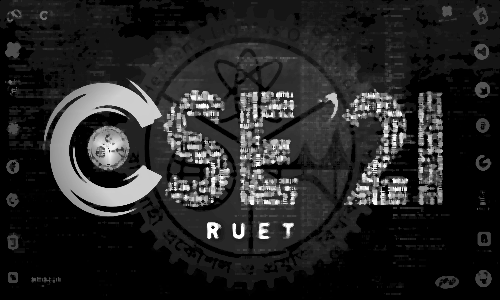

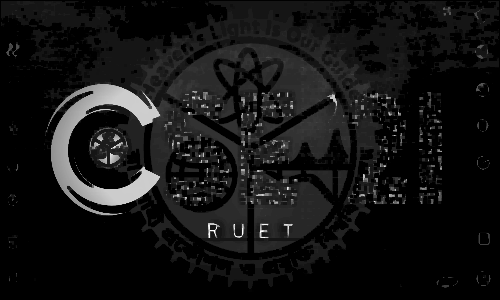

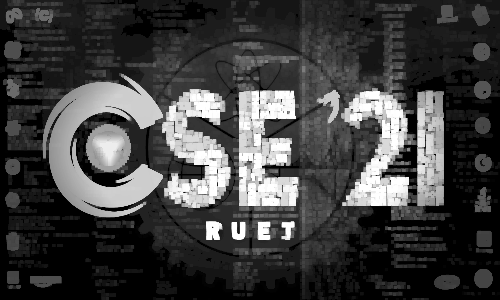

In [ ]:
filter=ManualFilter("/content/CSE-RUET Logo.png",300,500)
cv2_imshow(filter.median_filter())
cv2_imshow(filter.min_filter())
cv2_imshow(filter.max_filter())